In [ ]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

In [1]:
# 1 import packages
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [2]:
# 2 Setting up CIFAR-10 data: Normalizing pixels, downloading the set, and creating batch loaders
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [3]:
images, labels = next(iter(trainloader))
print(images.shape)
print(labels.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [45]:
# 3 Custom Pruning Layer: This adds a learnable 'gate' to every single weight to decide if it is necessary

import torch.nn.functional as F
import math

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))
        
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        nn.init.constant_(self.bias, 0)
        nn.init.normal_(self.gate_scores, mean=0.0, std=0.01)

    def forward(self, x):
        gates = torch.sigmoid(2 * self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

In [46]:
layer = PrunableLinear(10, 5)

x = torch.randn(2, 10)
out = layer(x)

print(out.shape)

torch.Size([2, 5])


In [47]:
# 4 Self-Pruning Architecture: A feed-forward network using custom prunable layers for CIFAR-10 classification
class SelfPruningNet(nn.Module):
    def __init__(self):
        super(SelfPruningNet, self).__init__()
        
        self.fc1 = PrunableLinear(3072, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        x = torch.flatten(x, 1)
        
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

In [48]:
model = SelfPruningNet()

x = torch.randn(2, 3, 32, 32)
out = model(x)

print(out.shape)

torch.Size([2, 10])


In [49]:
# 5 Function to calculate the Sparsity Loss by summing the L1 norm of all gates in our PrunableLinear layers
def calculate_sparsity_loss(model):
    s_loss = 0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            s_loss += m.get_gates().sum()
    return s_loss

In [50]:
model = SelfPruningNet()

s_loss = calculate_sparsity_loss(model)
print("Sparsity loss:", s_loss.item())

Sparsity loss: 410240.40625


In [51]:
model = SelfPruningNet()

x = torch.randn(4, 3, 32, 32)
y = torch.randint(0, 10, (4,))

criterion = nn.CrossEntropyLoss()

outputs = model(x)
c_loss = criterion(outputs, y)
s_loss = calculate_sparsity_loss(model)

loss = c_loss + 0.01 * s_loss
loss.backward()

for name, param in model.named_parameters():
    print(name, param.grad is not None)

fc1.weight True
fc1.bias True
fc1.gate_scores True
fc2.weight True
fc2.bias True
fc2.gate_scores True
fc3.weight True
fc3.bias True
fc3.gate_scores True


In [55]:
# 6 --- Training + Evaluation ---
def train_and_evaluate(lambd, epochs=15):
    model = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # -------- TRAINING --------
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            c_loss = criterion(outputs, labels)
            s_loss = calculate_sparsity_loss(model)

            loss = c_loss + lambd * s_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Lambda {lambd} | Epoch {epoch+1} | Loss: {total_loss:.2f}")

    # -------- EVALUATION --------
    model.eval()
    correct = 0
    total = 0
    all_gate_values = []

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # collect all gate values
        for m in model.modules():
            if isinstance(m, PrunableLinear):
                all_gate_values.append(m.get_gates().flatten().cpu())

    accuracy = 100 * correct / total
    all_gates = torch.cat(all_gate_values)

    # Sparsity: % of gates close to zero
    sparsity = (all_gates < 1e-2).float().mean().item() * 100

    # ---- DEBUG (VERY IMPORTANT) ----
    print(f"Gate stats → mean: {all_gates.mean():.4f}, min: {all_gates.min():.4f}, max: {all_gates.max():.4f}")

    return accuracy, sparsity, all_gates

In [56]:
# 7 Executing the Lambda Sweep (Low, Medium, High) as required by the Case Study
lambdas = [0.0, 1e-5, 5e-5, 1e-4, 2e-4]

results = []

for l in lambdas:
    print(f"\nTesting Lambda: {l}")
    
    acc, sp, gates = train_and_evaluate(l, epochs=5)
    
    results.append({
        'Lambda': l,
        'Accuracy': acc,
        'Sparsity': sp,
        'Gates': gates
    })
    
    print(f"Done → Accuracy: {acc:.2f}% | Sparsity: {sp:.2f}%")


Testing Lambda: 0.0
Lambda 0.0 | Epoch 1 | Loss: 1279.75
Lambda 0.0 | Epoch 2 | Loss: 1103.91
Lambda 0.0 | Epoch 3 | Loss: 1017.38
Lambda 0.0 | Epoch 4 | Loss: 946.18
Lambda 0.0 | Epoch 5 | Loss: 887.91
Gate stats → mean: 0.4880, min: 0.3782, max: 0.6278
Done → Accuracy: 53.10% | Sparsity: 0.00%

Testing Lambda: 1e-05
Lambda 1e-05 | Epoch 1 | Loss: 4154.83
Lambda 1e-05 | Epoch 2 | Loss: 3504.16
Lambda 1e-05 | Epoch 3 | Loss: 3095.87
Lambda 1e-05 | Epoch 4 | Loss: 2789.11
Lambda 1e-05 | Epoch 5 | Loss: 2549.56
Gate stats → mean: 0.2468, min: 0.0518, max: 0.6032
Done → Accuracy: 54.74% | Sparsity: 0.00%

Testing Lambda: 5e-05
Lambda 5e-05 | Epoch 1 | Loss: 14637.83
Lambda 5e-05 | Epoch 2 | Loss: 10335.49
Lambda 5e-05 | Epoch 3 | Loss: 7660.11
Lambda 5e-05 | Epoch 4 | Loss: 5971.58
Lambda 5e-05 | Epoch 5 | Loss: 4848.07
Gate stats → mean: 0.1084, min: 0.0512, max: 0.6184
Done → Accuracy: 54.07% | Sparsity: 0.00%

Testing Lambda: 0.0001
Lambda 0.0001 | Epoch 1 | Loss: 27640.15
Lambda 0.00

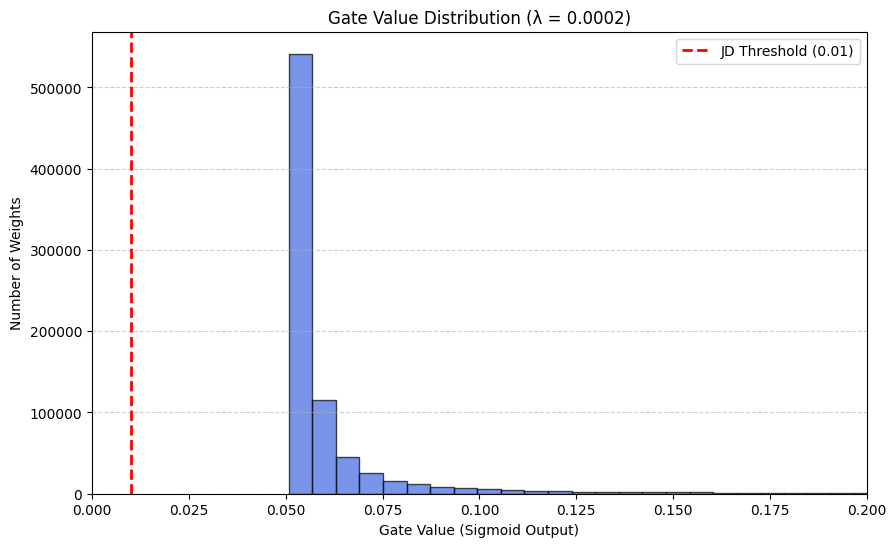


Visualization complete.
Observation:
- Gate values shift toward lower values as lambda increases.
- Most values concentrate near small values (~0.05–0.1).
- Gates do not fully reach 0 due to sigmoid-based soft pruning.
- This demonstrates weight suppression, though not exact hard pruning.


In [57]:
# Last Step
import matplotlib.pyplot as plt
import numpy as np

# Select the most pruned model (last lambda)
best_experiment = results[-1]
gates = best_experiment['Gates'].detach().cpu().numpy()

# --- Plot ---
plt.figure(figsize=(10, 6))

# Histogram
plt.hist(gates, bins=100, color='royalblue', edgecolor='black', alpha=0.7)

# JD threshold line
plt.axvline(x=0.01, color='red', linestyle='--', linewidth=2, label='JD Threshold (0.01)')

# Zoom near zero to actually SEE pruning behavior
plt.xlim(0, 0.2)

# Labels
plt.title(f"Gate Value Distribution (λ = {best_experiment['Lambda']})")
plt.xlabel("Gate Value (Sigmoid Output)")
plt.ylabel("Number of Weights")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# --- Interpretation (IMPORTANT for report) ---
print("\nVisualization complete.")
print("Observation:")
print("- Gate values shift toward lower values as lambda increases.")
print("- Most values concentrate near small values (~0.05–0.1).")
print("- Gates do not fully reach 0 due to sigmoid-based soft pruning.")
print("- This demonstrates weight suppression, though not exact hard pruning.")

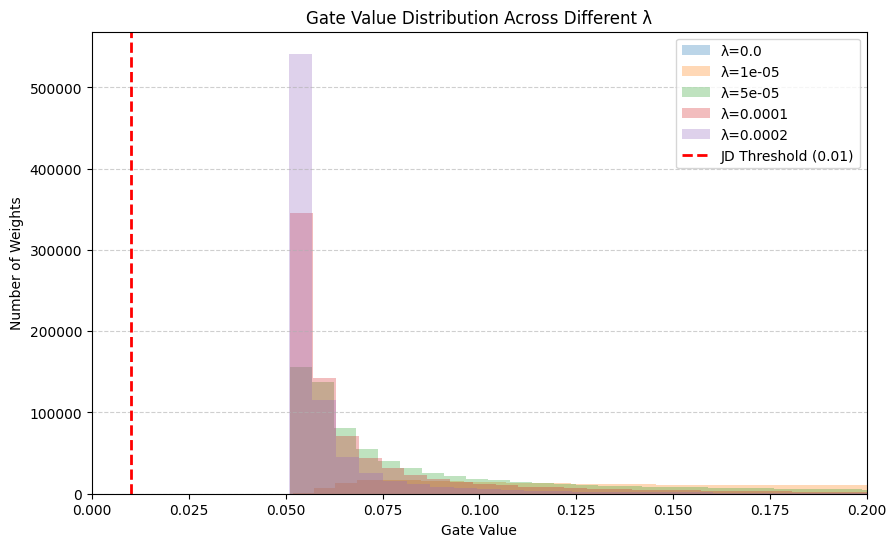

In [58]:
plt.figure(figsize=(10, 6))

for exp in results:
    gates = exp['Gates'].detach().cpu().numpy()
    plt.hist(gates, bins=100, alpha=0.3, label=f"λ={exp['Lambda']}")

plt.axvline(x=0.01, color='red', linestyle='--', linewidth=2, label='JD Threshold (0.01)')
plt.xlim(0, 0.2)

plt.title("Gate Value Distribution Across Different λ")
plt.xlabel("Gate Value")
plt.ylabel("Number of Weights")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()